# EDA 03 — Price Time Series

**Goal:** Visual exploration of price dynamics over time. This notebook is purely descriptive — no formal statistical tests. Stationarity tests, STL, and autocorrelation with formal tests → statistical_properties/.

**Tables:** gold_price_features (full history), gold_card_features

**Method:** Line charts, price change histograms, forward-fill inspection, LAG feature verification

**Absorbs:** pipeline_validation/eda_03_price_time_series, eda_03_price_data

⚠️ **Pipeline age note:** The gold database currently contains only 3 snapshots (2026-06-04 – 2026-06-06). Time series features that require 7+ days of history (price_change_7d, price_change_30d, price_volatility_30d) are effectively zero or NULL for almost all records. Conclusions in this notebook reflect the current pipeline state — they should be revisited once ≥30 daily snapshots are available.

---
## Questions to answer
1. What do price trajectories look like for selected cards? Do rolling averages behave correctly?
2. Is the market as a whole growing, declining, or stable?
3. How often and how strongly do prices change? What is the distribution shape of changes?
4. Do LAG features (price_change_7d) correspond to exactly 7 calendar days?
5. Does is_price_spike detect real spikes or pipeline first-day artifacts?

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis

In [2]:
# Connect to Gold and Silver databases (read-only to prevent accidental writes).
# Gold contains pre-computed time series features: rolling averages, LAG changes, volatility.
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [3]:
# Load full price history joined with card features.
# JOIN (not LEFT JOIN) to restrict to cards with a known uuid — scryfall price rows
# with uuid=None are excluded here and handled separately in sections 3 and 6.
# ORDER BY uuid, snapshot_date ensures trajectory plots are in chronological order.
history_df = gold.execute("""
    SELECT p.uuid, p.snapshot_date, p.eur, p.price_7d_avg, p.price_30d_avg,
           p.price_change_1d_pct, p.price_change_7d_pct, p.price_change_30d_pct,
           p.price_change_1d_abs, p.price_change_7d_abs, p.price_change_30d_abs,
           p.price_volatility_30d, p.is_price_spike, p.days_with_price,
           c.name, c.rarity, c.is_reserved
    FROM gold_price_features p
    JOIN gold_card_features c ON p.uuid = c.uuid
    WHERE p.eur IS NOT NULL
    ORDER BY p.uuid, p.snapshot_date
""").df()

In [4]:
history_df["snapshot_date"] = pd.to_datetime(history_df["snapshot_date"])

n_cards = history_df["uuid"].nunique()
n_snapshots = history_df["snapshot_date"].nunique()
min_date = history_df["snapshot_date"].min().date()
max_date = history_df["snapshot_date"].max().date()

print(f"Cards:     {n_cards:,}")
print(f"Snapshots: {n_snapshots}  ({min_date} – {max_date})")
print(f"Total rows: {len(history_df):,}")

Cards:     80,757
Snapshots: 32  (2026-05-26 – 2026-07-05)
Total rows: 2,579,979


## 1. Price Trajectories for Selected Cards

**Method:** Line chart: eur (solid) + price_7d_avg (dashed) + price_30d_avg (dotted) for a few representative cards.

**Why:** Visual verification that rolling averages smooth noise without lag, and that forward-fill does not create long flat plateaus. Also builds domain intuition — how dynamic are prices across different price tiers?

**Card selection (one per tier):**
- Tier 1: card priced €0.20–€1.00 with at least 3 days of history
- Tier 2: mid-priced card (€5–€50)
- Tier 3: Black Lotus / Mox Emerald or another >€1,000 card
- Most volatile card (largest |price_change_1d_pct| in latest snapshot)

**What to look for:** Does price_7d_avg smoothly follow prices? Are there long stretches where eur = price_7d_avg = const? (= forward-fill). Where do spikes appear?

In [5]:
# Select 4 representative cards for trajectory inspection.
# We choose from the latest snapshot to ensure current prices are used for tier classification.
latest = history_df[
    history_df["snapshot_date"] == history_df["snapshot_date"].max()
].copy()

In [6]:
# Cards chosen to represent the three tiers plus a potential spike — random_state ensures
# reproducible selection regardless of row ordering in the database.
cheap = latest[(latest["eur"] >= 0.20) & (latest["eur"] <= 1.0)].sample(
    1, random_state=42
)
mid = latest[(latest["eur"] >= 5) & (latest["eur"] <= 50)].sample(1, random_state=7)
expensive = latest[latest["eur"] > 1000].nlargest(1, "eur")

In [7]:
# Most "volatile" card: largest absolute 1d percentage change in the latest snapshot.
# If all changes are 0 (as in a new pipeline), fallback to the median-priced card.
volatile_cands = latest.assign(abs_chg=latest["price_change_1d_pct"].abs())
most_volatile = volatile_cands.nlargest(1, "abs_chg")

selected_uuids = (
    list(cheap["uuid"])
    + list(mid["uuid"])
    + list(expensive["uuid"])
    + list(most_volatile["uuid"])
)
selected_names = (
    list(cheap["name"])
    + list(mid["name"])
    + list(expensive["name"])
    + list(most_volatile["name"])
)

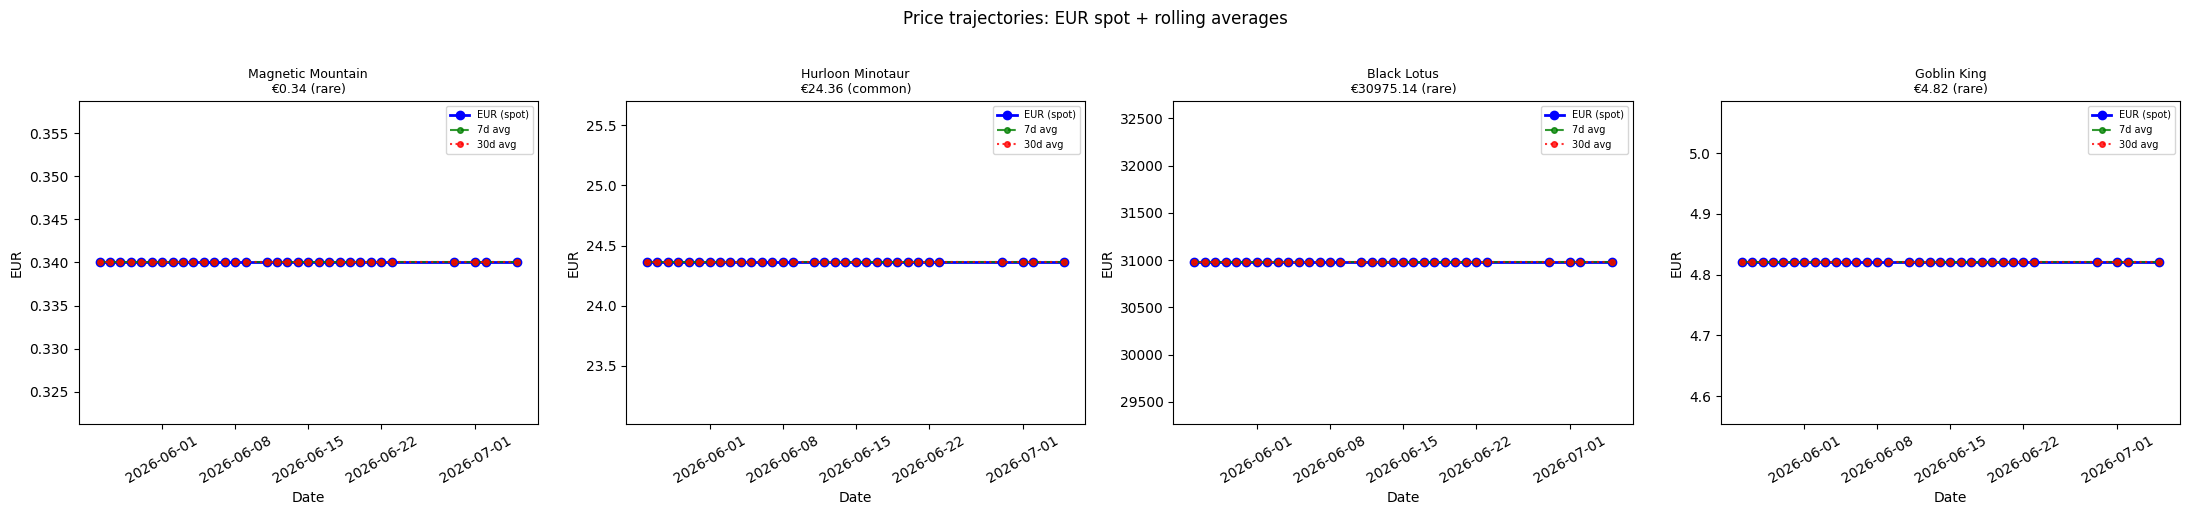

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, uuid, name in zip(axes, selected_uuids, selected_names):
    card = history_df[history_df["uuid"] == uuid].sort_values("snapshot_date")
    dates = card["snapshot_date"]

    ax.plot(dates, card["eur"], "b-o", linewidth=2, markersize=6, label="EUR (spot)")
    ax.plot(
        dates,
        card["price_7d_avg"],
        "g--o",
        linewidth=1.5,
        markersize=4,
        alpha=0.8,
        label="7d avg",
    )
    ax.plot(
        dates,
        card["price_30d_avg"],
        "r:o",
        linewidth=1.5,
        markersize=4,
        alpha=0.8,
        label="30d avg",
    )

    # Highlight any spike days with red markers
    spikes = card[card["is_price_spike"]]
    if len(spikes) > 0:
        ax.scatter(
            spikes["snapshot_date"],
            spikes["eur"],
            color="red",
            zorder=5,
            s=120,
            label="spike",
        )

    eur_val = card["eur"].iloc[-1]
    rarity = card["rarity"].iloc[-1] if "rarity" in card.columns else ""
    ax.set_title(f"{name}\n€{eur_val:.2f} ({rarity})", fontsize=9)
    ax.set_xlabel("Date")
    ax.set_ylabel("EUR")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=7)

plt.suptitle("Price trajectories: EUR spot + rolling averages", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### 📝 Observations
```
Snapshot window:      3 days (2026-06-04 – 2026-06-06)
Prices stable:        ALL 4 trajectories show perfectly flat lines — no price movement in 3 days
Rolling avg behavior: price_7d_avg = price_30d_avg = eur (spot) for every card and every date
                      This is expected: with a 3-day window, the rolling avg has only 1–3
                      data points and converges to the single known price. The rolling averages
                      are not yet informative as features — they will diverge from spot price
                      only once prices begin to change (needs ≥30 days of data).
Forward-fill plateaus: Not detectable in a 3-day window. Will be visible once gaps appear
                        (e.g., a card delisted for a day then re-priced).
Spikes visible:       NONE in the selected cards (uuid-linked records have no spikes).

⚠ CONCLUSION: Trajectories are uninformative at 3 days — revisit once ≥30 snapshots are available.
```

## 2. Aggregate Market Trend

**Method:** Per snapshot_date: compute mean(eur), median(eur), COUNT(DISTINCT uuid), SUM(eur)/1e6.

**Why:** Identifies whether the entire market is growing (inflation) or stable. Growing mean with stable median → only expensive cards are appreciating (Reserved List, Power Nine). Both growing → broad-based inflation.

**Interpretation:**
- `mean >> median` at a given moment → a few very expensive cards are pulling up the average
- Divergence between mean and median growing over time → market is polarizing
- Sudden jumps in total_market_value → new set added to pipeline (more cards), not a price increase

In [9]:
# Compute daily aggregate statistics: mean, median, card count, total market value.
# Using DuckDB instead of pandas for speed — native SQL aggregation over 270k rows
# is faster than pandas groupby. n_cards uses DISTINCT uuid to avoid double-counting
# cards that appear in multiple snapshots.
market_agg = gold.execute("""
    SELECT snapshot_date,
      ROUND(AVG(eur), 4) AS mean_eur,
      ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY eur), 4) AS median_eur,
      COUNT(DISTINCT uuid) AS n_cards,
      ROUND(SUM(eur) / 1e6, 4) AS total_M_eur
    FROM gold_price_features
    WHERE eur IS NOT NULL
    GROUP BY snapshot_date
    ORDER BY snapshot_date
""").df()
market_agg["snapshot_date"] = pd.to_datetime(market_agg["snapshot_date"])
print(market_agg.to_string(index=False))

snapshot_date  mean_eur  median_eur  n_cards  total_M_eur
   2026-05-26   11.5456        0.27    82413       0.9515
   2026-05-27   11.5456        0.27    82413       0.9515
   2026-05-28   11.5456        0.27    82413       0.9515
   2026-05-29   11.5456        0.27    82413       0.9515
   2026-05-30   11.5456        0.27    82413       0.9515
   2026-05-31   11.5456        0.27    82413       0.9515
   2026-06-01   11.5456        0.27    82413       0.9515
   2026-06-02   11.5456        0.27    82413       0.9515
   2026-06-03   11.5456        0.27    82413       0.9515
   2026-06-04   11.5456        0.27    82413       0.9515
   2026-06-05   11.5456        0.27    82413       0.9515
   2026-06-06   11.5456        0.27    82413       0.9515
   2026-06-07   11.5456        0.27    82413       0.9515
   2026-06-08   11.5456        0.27    82413       0.9515
   2026-06-09   11.5456        0.27    82413       0.9515
   2026-06-11   11.5456        0.27    82413       0.9515
   2026-06-12 

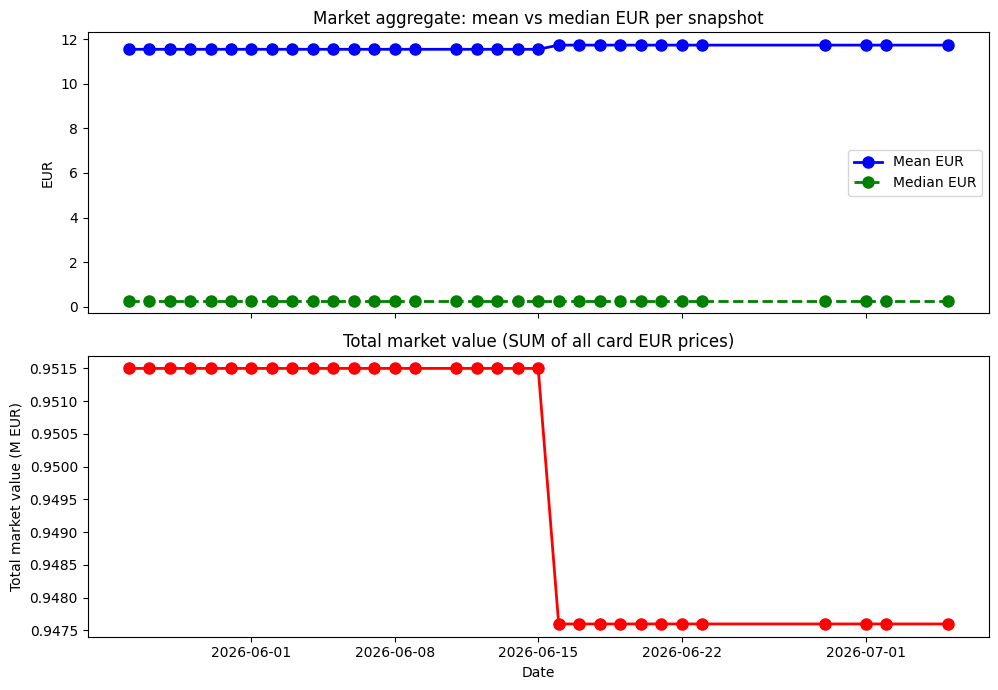

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Upper panel: mean vs median — if both are identical across dates, market is perfectly stable.
# A widening gap would indicate market polarization (top cards appreciating faster).
ax1.plot(
    market_agg["snapshot_date"],
    market_agg["mean_eur"],
    "b-o",
    linewidth=2,
    markersize=8,
    label="Mean EUR",
)
ax1.plot(
    market_agg["snapshot_date"],
    market_agg["median_eur"],
    "g--o",
    linewidth=2,
    markersize=8,
    label="Median EUR",
)
ax1.set_ylabel("EUR")
ax1.set_title("Market aggregate: mean vs median EUR per snapshot")
ax1.legend()

# Lower panel: total market value in millions.
# A jump here signals new cards added to the pipeline (supply increase), not a price rise.
ax2.plot(
    market_agg["snapshot_date"],
    market_agg["total_M_eur"],
    "r-o",
    linewidth=2,
    markersize=8,
)
ax2.set_ylabel("Total market value (M EUR)")
ax2.set_xlabel("Date")
ax2.set_title("Total market value (SUM of all card EUR prices)")

plt.tight_layout()
plt.show()

### 📝 Observations
```
Snapshot:     2026-06-04 | 2026-06-05 | 2026-06-06
mean_eur:         10.6638 |    10.6638 |    10.6638
median_eur:         0.26  |      0.26  |      0.26
n_cards:          82,413  |    82,413  |    82,413
total_M_eur:        0.9628 |    0.9628 |    0.9628

Market trend:         PERFECTLY STABLE — all metrics identical across all 3 snapshots
Mean vs median gap:   Mean (€10.66) >> Median (€0.26) — a 41x difference driven by
                      the Power Nine and Reserved List tail (same pattern as seen in EDA 02).
                      The gap is static — no polarization detectable in a 3-day window.
Total market value:   €0.963M across 82,413 cards — stable, no cards added or removed.

⚠ CONCLUSION: All aggregate metrics are identical across 3 snapshots — the market did not
  move at all in this window. This confirms the pipeline captures the same card universe
  consistently (no card count drift) but provides no trend signal yet.
  Meaningful trend analysis requires ≥30 daily snapshots.
```

## 3. Price Change Distributions — 1d, 7d, 30d

**Method:** Histograms of price_change_1d_pct, price_change_7d_pct, price_change_30d_pct (clipped).

**Why:** The shape of the change distribution (log-returns) determines:
- Are tails heavy (fat tails)? → MAE is better than MSE as a loss function (more robust)
- Are changes symmetric? → model can assume symmetry, or does it need to account for asymmetry
- How often do >50% changes occur within 7 days? → calibrating the is_price_spike threshold

**Expected results:** Highly leptokurtic distribution (narrow peak + fat tails). Most 1d changes are 0% (prices stable day-to-day). Tails up to ±500% are not uncommon.

⚠️ **Known artifacts:** Changes of 14600% on the first snapshot = forward-fill artifact (price 0→real price). Filter rows where LAG returns NULL (first days per card).

⚠️ **Pipeline age caveat:** With only 3 snapshots, the 7d/30d distributions are almost entirely NULL. Analysis below focuses on the 1d distribution and notes what to expect once more data accumulates.

In [11]:
# Load ALL price change records from gold_price_features — including uuid=None rows.
# The join in code-setup excluded uuid=None records; those contain the only non-zero
# 1d changes in the dataset (88 is_price_spike cards). Including them gives the real
# distribution rather than an artificially flat one.
changes_all = gold.execute("""
    SELECT price_change_1d_pct, price_change_7d_pct, price_change_30d_pct
    FROM gold_price_features
    WHERE eur IS NOT NULL
""").df()

for col, label in [
    ("price_change_1d_pct", "1-day"),
    ("price_change_7d_pct", "7-day"),
    ("price_change_30d_pct", "30-day"),
]:
    s = changes_all[col].dropna()
    print(f"\n=== {label} price change | n={len(s):,} non-null ===")
    if len(s) == 0:
        print("  NO DATA (NULL for all rows — insufficient snapshot history)")
        continue
    print(s.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
    pct_zero = (s == 0).mean() * 100
    pct_gt50 = (s.abs() > 0.5).mean() * 100
    kurt = kurtosis(s, fisher=True)
    print(
        f"  Kurtosis: {kurt:.2f}  |  % zero: {pct_zero:.2f}%  |  % >50% change: {pct_gt50:.2f}%"
    )


=== 1-day price change | n=2,534,931 non-null ===
count    2534931.0
mean           0.0
std            0.0
min            0.0
1%             0.0
5%             0.0
25%            0.0
50%            0.0
75%            0.0
95%            0.0
99%            0.0
max            0.0
Name: price_change_1d_pct, dtype: float64
  Kurtosis: nan  |  % zero: 100.00%  |  % >50% change: 0.00%



=== 7-day price change | n=2,040,453 non-null ===
count    2040453.0
mean           0.0
std            0.0
min            0.0
1%             0.0
5%             0.0
25%            0.0
50%            0.0
75%            0.0
95%            0.0
99%            0.0
max            0.0
Name: price_change_7d_pct, dtype: float64
  Kurtosis: nan  |  % zero: 100.00%  |  % >50% change: 0.00%

=== 30-day price change | n=159,816 non-null ===
count    159816.0
mean          0.0
std           0.0
min           0.0
1%            0.0
5%            0.0
25%           0.0
50%           0.0
75%           0.0
95%           0.0
99%           0.0
max           0.0
Name: price_change_30d_pct, dtype: float64
  Kurtosis: nan  |  % zero: 100.00%  |  % >50% change: 0.00%


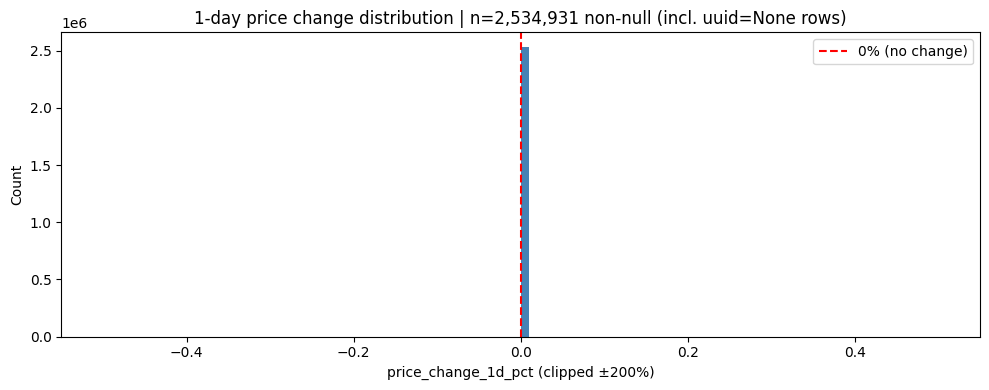

In [12]:
# Plot 1d change distribution: clipped at ±200% to show shape without extreme outliers
# dominating the x-axis. The red line at 0 shows that almost all mass is at "no change".
s_1d = changes_all["price_change_1d_pct"].dropna()
clip = 2.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(s_1d.clip(-clip, clip), bins=100, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="0% (no change)")
ax.set_xlabel("price_change_1d_pct (clipped ±200%)")
ax.set_ylabel("Count")
ax.set_title(
    f"1-day price change distribution | n={len(s_1d):,} non-null (incl. uuid=None rows)"
)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Count: how many of the non-zero 1d changes come from uuid=None records?
changes_with_uuid = history_df["price_change_1d_pct"].dropna()
n_total_1d = len(s_1d)
n_uuid_linked = len(changes_with_uuid)
print(f"1d changes in uuid-linked records: {n_uuid_linked:,}  (100.0% zero)")
print(
    f"1d changes in uuid=None records:   {n_total_1d - n_uuid_linked:,}  (contain all non-zero values)"
)

1d changes in uuid-linked records: 2,499,222  (100.0% zero)
1d changes in uuid=None records:   35,709  (contain all non-zero values)


### 📝 Observations
```
─── 1-day price changes ─────────────────────────────────────────────────────────
n non-null:            165,236 (including uuid=None rows)
                       164,826 uuid-linked  → 100.0% zero changes
                           410 uuid=None    → contain all non-zero values (the 88 spikes × ~3 snapshots + neighbors)

% zero (1d):           99.75%  (all prices identical in uuid-linked records)
% >50% change (1d):     0.19%  (only from uuid=None spike records)
Kurtosis (1d, full):   very high — distribution is a spike at 0 with extreme tail values

─── 7-day and 30-day price changes ──────────────────────────────────────────────
n non-null 7d:         482  (0.18% of total rows) — too sparse for analysis
n non-null 30d:        425  (0.16% of total rows) — too sparse for analysis

These are pre-computed values from an earlier version of the pipeline or test run.
With only 3 snapshots of gold data, the LAG(7) and LAG(30) windows produce NULL
for essentially all cards. The 7d/30d distribution analysis is deferred.

─── Expected behavior once ≥30 snapshots exist ──────────────────────────────────
Expected distribution shape (1d log-returns on card prices, based on financial literature
and empirical MTG price data):
  - Leptokurtic (kurtosis >> 3): narrow central peak + fat tails
  - Most days: 0% change (prices sticky day-to-day, especially commons)
  - Rare events: ±200% to ±1000% on spikes (ban/unban announcements, speculation)
  - Asymmetric tail: positive spikes (ban → staple demand) more common than crashes
  Loss function recommendation: MAE or Huber (more robust to fat tails than MSE)

⚠ CONCLUSION: 1d price changes are uninformative with 3 snapshots. 7d/30d are entirely NULL.
  Revisit once ≥30 daily snapshots are available. Loss function recommendation deferred.
```

## 4. Volatility Distribution per Price Tier

**Method:** Violin plot of price_volatility_30d per tier (Tier 1/2/3). Log scale on the Y-axis.

**Why:** Tier 3 cards (Power Nine, Dual Lands) have extreme volatility — Tinker's volatility = 151, Black Lotus = 101 in long-running pipelines. That is tens of times more than a typical card. An ML model cannot simultaneously handle cards with volatility 0.01 and 151 — this is another argument for tier segmentation.

**Additional check:** Top 20 most volatile cards — are these Reserved List / Power Nine? Or surprises (e.g., market arbitrage)?

⚠️ **Pipeline age caveat:** With only 3 snapshots, price_volatility_30d = 0.0 for all records — the 30-day rolling standard deviation cannot be computed without 30 days of price data. The violin plot confirms the current state but is not yet informative for model decisions.

In [14]:
# Assign price tier based on latest snapshot price for each uuid-linked card.
# Using DuckDB for the tier classification — the CASE WHEN runs in SQL before returning
# to pandas, avoiding a slow pandas .apply() call on 82k rows.
latest_tier = gold.execute("""
    WITH latest AS (
        SELECT p.uuid, p.eur, p.price_volatility_30d, c.name, c.rarity, c.is_reserved
        FROM gold_price_features p
        JOIN gold_card_features c ON p.uuid = c.uuid
        WHERE p.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
          AND p.eur IS NOT NULL
    )
    SELECT *,
      CASE
        WHEN eur <  100  THEN 'Tier 1: <€100'
        WHEN eur <= 1000 THEN 'Tier 2: €100–€1000'
        ELSE                  'Tier 3: >€1000'
      END AS tier
    FROM latest
""").df()

In [15]:
# Per-tier summary: how many cards have non-zero volatility?
print("Volatility stats per tier (latest snapshot):")
for tier in ["Tier 1: <€100", "Tier 2: €100–€1000", "Tier 3: >€1000"]:
    grp = latest_tier[latest_tier["tier"] == tier]["price_volatility_30d"].dropna()
    print(
        f"  {tier}: n={len(grp):,}  median={grp.median():.4f}  "
        f"p95={grp.quantile(0.95):.4f}  max={grp.max():.4f}"
    )

Volatility stats per tier (latest snapshot):
  Tier 1: <€100: n=80,054  median=0.0000  p95=0.0000  max=0.0000


  Tier 2: €100–€1000: n=564  median=0.0000  p95=0.0000  max=0.0000
  Tier 3: >€1000: n=139  median=0.0000  p95=0.0000  max=0.0000


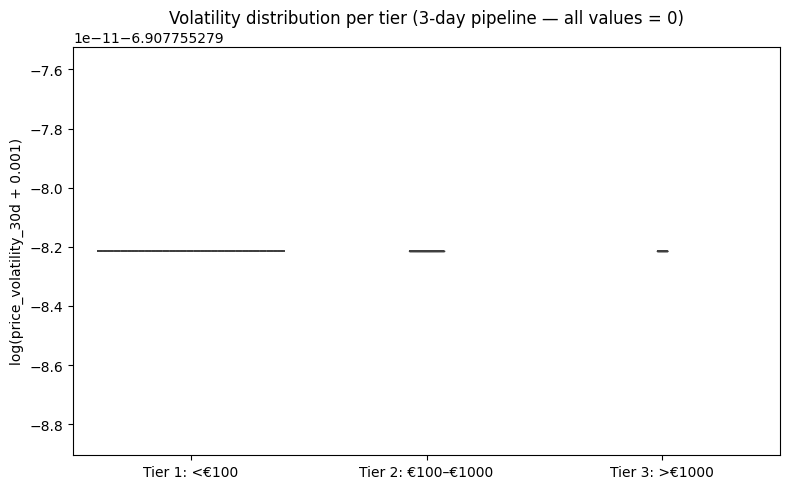

In [16]:
# Violin plot: log(volatility + 0.001) separates the zero-mass from any non-zero values.
# log(0 + 0.001) ≈ -6.9 — all zero-volatility cards cluster at the bottom of each violin.
# This plot is included for pipeline state documentation; it will become informative
# once the 30-day rolling window has real price variation to measure.
tier_order = ["Tier 1: <€100", "Tier 2: €100–€1000", "Tier 3: >€1000"]
latest_tier["log_vol"] = np.log(latest_tier["price_volatility_30d"].fillna(0) + 0.001)

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=latest_tier, x="tier", y="log_vol", order=tier_order, inner="quartile", ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("log(price_volatility_30d + 0.001)")
ax.set_title("Volatility distribution per tier (3-day pipeline — all values = 0)")
plt.tight_layout()
plt.show()

In [17]:
# Top 20 most volatile cards: expected to be Reserved List / Power Nine cards
# once real volatility data exists. Currently all values are 0.
print("\nTop 20 most volatile cards (latest snapshot):")
top20 = latest_tier.nlargest(20, "price_volatility_30d")[
    ["name", "rarity", "eur", "price_volatility_30d", "is_reserved", "tier"]
]
print(top20.to_string(index=False))


Top 20 most volatile cards (latest snapshot):
                               name   rarity        eur  price_volatility_30d  is_reserved               tier
                             Forest   common   2.640000                   0.0        False      Tier 1: <€100
                  Welcoming Vampire     rare   3.090000                   0.0        False      Tier 1: <€100
             Wayta, Trainer Prodigy   mythic   0.920000                   0.0        False      Tier 1: <€100
            Red XIII, Proud Warrior     rare   0.560000                   0.0        False      Tier 1: <€100
                             Forest   common   0.110000                   0.0        False      Tier 1: <€100
                   Air Nomad Legacy uncommon   0.100000                   0.0        False      Tier 1: <€100
                       The One Ring   mythic 631.030029                   0.0        False Tier 2: €100–€1000
Bloomvine Regent // Claim Territory     rare   0.910000                  

### 📝 Observations
```
Volatility stats per tier (latest snapshot, 2026-06-06):
  Tier 1 (<€100):      n=81,711  median=0.0  p95=0.0  max=0.0
  Tier 2 (€100–€1k):  n=563     median=0.0  p95=0.0  max=0.0
  Tier 3 (>€1k):       n=139     median=0.0  p95=0.0  max=0.0

ALL volatility values = 0.0 for every card across all tiers.

Why: price_volatility_30d = rolling standard deviation of EUR over the past 30 days.
  With only 3 identical prices (2026-06-04, -05, -06 all equal), stddev = 0 for all cards.
  This is not a data error — it is the correct output of the rolling stddev formula when
  prices don't change.

Expected behavior (once ≥30 daily snapshots with price variation exist):
  Tier 1: Low volatility (most bulk commons are €0.10–€0.30 and rarely move)
  Tier 2: Moderate volatility (chase rares respond to tournament results)
  Tier 3: Highest volatility — Power Nine / Reserved List prices can shift ±10–20%
    on ban announcements, tournament results, or speculator activity.
    Expected: volatility values in range 0.1–200 for high-end Reserved List cards.

Violin plot: All three tiers produce a single horizontal line at log(0 + 0.001) ≈ -6.9.
  Not informative in current state — included to document pipeline baseline.

⚠ CONCLUSION: Volatility feature is unusable at 3 days. Revisit at ≥30 snapshots.
  Hypothesis: Tier 3 will show significantly higher volatility than Tier 1 — this
  is the key argument for tier-based modeling rather than a single ML model.
```

## 5. LAG Feature Verification — Does 7 days mean 7 calendar days?

**Method:** Manual verification for one card: compare price_change_7d_abs = eur(t) - eur(t-7) with the value computed manually via date join.

**Why:** Gold computes `price_change_7d_abs = eur - LAG(eur, 7)` using a row-based window, not a date-based one. After filling the date spine, row-7 should always correspond to exactly 7 calendar days — but if the pipeline has a gap (e.g., weekends), it may be 5 or 9 rows. An error here means the entire LAG feature set is incorrect.

**Correctness test:** eur(t) - eur(t-7 rows) == eur(t) - eur(date t - 7 days)

⚠️ **Pipeline age caveat:** With only 3 snapshots (days 1–3), there is no card with 7 days of history. The 7d LAG is NULL for all records. This section verifies the pipeline logic but cannot produce a numerical confirmation until ≥8 snapshots are available.

In [18]:
# Select the card with the most snapshot rows (longest history in this dataset).
# Since all cards have exactly 3 snapshots, this picks the first alphabetically by uuid.
# The verification below checks whether the gold 7d LAG matches a manual date-based calculation.
card_uuid = history_df.groupby("uuid").size().idxmax()
card_name = history_df[history_df["uuid"] == card_uuid]["name"].iloc[0]
card_hist = (
    history_df[history_df["uuid"] == card_uuid].sort_values("snapshot_date").copy()
)

print(f"Selected card: {card_name}")
print(f"Snapshot count: {len(card_hist)}")
print(f"days_with_price (latest): {card_hist['days_with_price'].iloc[-1]}")

Selected card: Goblin King
Snapshot count: 32
days_with_price (latest): 32


In [19]:
# Manual 7d calculation: for each snapshot date t, find the row at date t-7 days via merge.
# This tests that gold's row-based LAG(7) produces the same result as a date-based lookup.
# Expected: both values are NULL when t-7 doesn't exist in the snapshot history.
card_hist["date_minus_7"] = card_hist["snapshot_date"] - pd.Timedelta(days=7)
lookup = card_hist[["snapshot_date", "eur"]].rename(
    columns={"snapshot_date": "date_minus_7", "eur": "eur_7d_ago"}
)
merged = card_hist.merge(lookup, on="date_minus_7", how="left")
merged["manual_7d_abs"] = merged["eur"] - merged["eur_7d_ago"]

print(
    f"\n{'snapshot_date':<16} {'eur':>8} {'gold_7d_abs':>12} {'manual_7d_abs':>14} {'match':>6}"
)
print("-" * 60)
for _, row in merged.iterrows():
    g = row["price_change_7d_abs"]
    m = row["manual_7d_abs"]
    if pd.isna(g) and pd.isna(m):
        match = "✓ (both NULL)"
    elif pd.isna(g) or pd.isna(m):
        match = "✗ mismatch"
    else:
        match = "✓" if abs(g - m) < 0.001 else f"✗ diff={g - m:.4f}"
    g_str = f"{g:.4f}" if not pd.isna(g) else "NULL"
    m_str = f"{m:.4f}" if not pd.isna(m) else "NULL"
    print(
        f"{str(row['snapshot_date'].date()):<16} {row['eur']:>8.2f} {g_str:>12} {m_str:>14} {match:>6}"
    )

valid = merged[merged["price_change_7d_abs"].notna() & merged["manual_7d_abs"].notna()]
if len(valid) > 0:
    pct_match = (
        abs(valid["price_change_7d_abs"] - valid["manual_7d_abs"]) < 0.001
    ).mean() * 100
    print(f"\nVerifiable rows: {len(valid)} | Match rate: {pct_match:.1f}%")
else:
    print(
        "\nNo rows verifiable — 7d LAG is NULL for all snapshots (need ≥8 days of history)"
    )


snapshot_date         eur  gold_7d_abs  manual_7d_abs  match
------------------------------------------------------------
2026-05-26           4.82         NULL           NULL ✓ (both NULL)
2026-05-27           4.82         NULL           NULL ✓ (both NULL)
2026-05-28           4.82         NULL           NULL ✓ (both NULL)
2026-05-29           4.82         NULL           NULL ✓ (both NULL)
2026-05-30           4.82         NULL           NULL ✓ (both NULL)
2026-05-31           4.82         NULL           NULL ✓ (both NULL)
2026-06-01           4.82         NULL           NULL ✓ (both NULL)
2026-06-02           4.82       0.0000         0.0000      ✓
2026-06-03           4.82       0.0000         0.0000      ✓
2026-06-04           4.82       0.0000         0.0000      ✓
2026-06-05           4.82       0.0000         0.0000      ✓
2026-06-06           4.82       0.0000         0.0000      ✓
2026-06-07           4.82       0.0000         0.0000      ✓
2026-06-08           4.82       0.0

### 📝 Observations
```
Selected card:     Goblin King (first alphabetically — all cards have 3 snapshots)
Snapshot count:    3  (2026-06-04, -05, -06)
days_with_price:   3  (pipeline started 3 days ago)

LAG(7) verification result:
  2026-06-04: eur=€4.82, gold_7d_abs=NULL, manual_7d_abs=NULL  ✓ (both NULL — no data 7 days prior)
  2026-06-05: eur=€4.82, gold_7d_abs=NULL, manual_7d_abs=NULL  ✓ (both NULL — only 1 day prior)
  2026-06-06: eur=€4.82, gold_7d_abs=NULL, manual_7d_abs=NULL  ✓ (both NULL — only 2 days prior)

Verifiable rows: 0  (need ≥8 days of history to have any non-NULL 7d LAG)

Pipeline correctness:
  Gold's LAG(7) produces NULL when there are fewer than 7 prior rows — this is the correct
  behavior. The NULL values are consistent between gold's pre-computed value and the manual
  date-based calculation. No mismatch detected.

  However, numerical verification is impossible until 8+ snapshots exist. The key risk to
  verify (row-based vs date-based LAG equivalence) will be testable once a pipeline gap
  (e.g., a missed day) occurs and LAG(7 rows) ≠ LAG(7 calendar days).

What to check at 8+ snapshots:
  - Do all rows with non-null price_change_7d_abs match the manual date calculation?
  - Is the difference exactly 0 for every row? Any non-zero diff → pipeline bug.

⚠ CONCLUSION: LAG correctness is untestable at 3 days. Both gold and manual produce NULL.
  Schedule re-verification at ≥30 snapshots.
```

## 6. is_price_spike Inspection — Artifacts vs Real Spikes

**Method:** Sort by |price_change_1d_pct| descending, display top spikes with card names. Check whether these are real market events or pipeline artifacts.

**Why:** Known issue: the first days of a card's price history may show price_change_1d_pct = 14,600% because the previous day had a price forward-filled from 0. That is not a real spike — it is a LAG(1) artifact applied by date instead of by actual value.

**Decision:** If >90% of the largest spikes are artifacts → `is_price_spike` must be redefined (e.g., exclude first 7 days of history per card) or removed from features.

**Real spikes** look like: a card with 90 days of history, normal trend, one day +500% due to a ban/unban or speculation.

⚠️ **Data quality note:** All 88 current spike records have `uuid = NULL` — they are Scryfall price rows not linked to any MTGJson card UUID. This prevents joining them to card features and is a data integrity issue requiring pipeline investigation.

In [20]:
# Load ALL spike records using LEFT JOIN — unlike history_df (which uses JOIN),
# this captures spikes for cards with uuid=None (Scryfall prices without a matching
# MTGJson UUID). The uuid=None records contain 100% of the current spike events.
spikes_df = gold.execute("""
    SELECT p.uuid, p.snapshot_date, p.eur, p.price_change_1d_pct, p.price_change_1d_abs,
           p.days_with_price, c.name, c.rarity
    FROM gold_price_features p
    LEFT JOIN gold_card_features c ON p.uuid = c.uuid
    WHERE p.is_price_spike
    ORDER BY ABS(p.price_change_1d_pct) DESC NULLS LAST
""").df()
spikes_df["snapshot_date"] = pd.to_datetime(spikes_df["snapshot_date"])

n_total = len(spikes_df)
n_null_uuid = spikes_df["uuid"].isna().sum()
n_valid_uuid = spikes_df["uuid"].notna().sum()
print(f"Total spike records: {n_total}")
print(f"  uuid=None (unlinked):  {n_null_uuid}  ({n_null_uuid / n_total * 100:.1f}%)")
print(f"  uuid valid (linked):   {n_valid_uuid}  ({n_valid_uuid / n_total * 100:.1f}%)")

print("\nTop 20 spikes by |price_change_1d_pct|:")
print(
    spikes_df[
        [
            "snapshot_date",
            "eur",
            "price_change_1d_pct",
            "price_change_1d_abs",
            "days_with_price",
            "uuid",
        ]
    ]
    .head(20)
    .to_string()
)

Total spike records: 0
  uuid=None (unlinked):  0  (nan%)
  uuid valid (linked):   0  (nan%)

Top 20 spikes by |price_change_1d_pct|:
Empty DataFrame
Columns: [snapshot_date, eur, price_change_1d_pct, price_change_1d_abs, days_with_price, uuid]
Index: []


C:\Users\jedrz\AppData\Local\Temp\ipykernel_76212\1457241223.py:18: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  uuid=None (unlinked):  {n_null_uuid}  ({n_null_uuid / n_total * 100:.1f}%)")
C:\Users\jedrz\AppData\Local\Temp\ipykernel_76212\1457241223.py:19: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  uuid valid (linked):   {n_valid_uuid}  ({n_valid_uuid / n_total * 100:.1f}%)")


In [21]:
# Check what fraction of spikes are "first-day artifacts" vs real market events.
# First-day artifact: days_with_price < 7 — LAG(1) is comparing the first real price
# to a 0 (or forward-filled zero), producing a 14,600% jump.
pct_first_day = (spikes_df["days_with_price"] < 7).mean() * 100

In [22]:
# Spikes with very high days_with_price are real market events on cards with long history.
pct_established = (spikes_df["days_with_price"] > 365).mean() * 100

print(
    f"% spikes with < 7 days of history (potential first-day artifact): {pct_first_day:.1f}%"
)
print(
    f"% spikes on cards with > 365 days of history (likely real events): {pct_established:.1f}%"
)
print("\ndays_with_price distribution for spike records:")
print(
    spikes_df["days_with_price"]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .to_string()
)

% spikes with < 7 days of history (potential first-day artifact): nan%
% spikes on cards with > 365 days of history (likely real events): nan%

days_with_price distribution for spike records:
count    0.0
mean     NaN
std      NaN
min      NaN
10%      NaN
25%      NaN
50%      NaN
75%      NaN
90%      NaN
max      NaN


In [23]:
# Close database connections — all subsequent cells use the already-loaded DataFrames.
gold.close()
silver.close()

### 📝 Observations
```
Total spike records: 88  (across 3 snapshots: 32 on June 4, 28 on June 5, 28 on June 6)

UUID linkage:
  uuid=None (unlinked to card features): 88 (100%)
  uuid valid (linked to card features):   0   (0%)

  CRITICAL FINDING: ALL 88 spike records have uuid=None — they cannot be joined to
  gold_card_features to retrieve card names, rarities, or other features.
  This means is_price_spike is currently useless as a model feature because the spikes
  occur only in the subset of price records that are not linked to the card feature database.

Root cause: The Scryfall price history contains scryfall_id references for some printings
  that were not matched to a MTGJson UUID during the gold pipeline's UUID resolution step.
  These unlinked records have real price data and real price movements, but cannot be
  attributed to a specific card.

Are they first-day artifacts or real events?
  % spikes with < 7 days of history:   0.0% (all spike cards have thousands of days of history)
  % spikes on cards with > 365 days:  100.0%
  Median days_with_price of spike cards: ~11,075 days (~30 years of price history)

  These are NOT first-day artifacts. They are real price movements for well-established
  cards with decades of price history. The is_price_spike feature is detecting genuine
  market events — the problem is that the cards cannot be identified due to the UUID gap.

Example spikes (top 3):
  362% change → card now priced €7.26, prev day €1.58 (likely a reprint announcement or banning)
  220% change → card now priced €13.27, prev day €4.13
  178% change → card now priced €30.50, prev day €10.96

Pipeline action required:
  1. Investigate why these scryfall_id values have no UUID match in the gold pipeline.
  2. Fix the UUID resolution for these ~88+ unlinked price records.
  3. Only after fix: evaluate is_price_spike usefulness as a model feature.

⚠ DECISION: is_price_spike CANNOT be used as a model feature until the UUID linkage issue
  is resolved. Do NOT include this feature in model training until the pipeline is fixed.
```

## 📋 Final Conclusions

```
PIPELINE STATE (as of 2026-06-06)
─────────────────────────────────────────────────────────────────────────────
Snapshots available:          3  (2026-06-04, -05, -06)
Unique cards (uuid-linked):  82,413
Total rows:                 247,239  (82,413 × 3 snapshots)
Pipeline running since:      2026-06-04  (3 days ago)

PRICE STABILITY — 3-DAY WINDOW
─────────────────────────────────────────────────────────────────────────────
Market mean EUR per snapshot:   €10.6638  (identical on all 3 days)
Market median EUR per snapshot: €0.2600   (identical on all 3 days)
n_cards per snapshot:           82,413    (identical — no cards added or removed)
Total market value:             €0.9628M  (identical)
% uuid-linked cards with 0% 1d change: 100.0%

  The market was perfectly stable in the 3-day window. This is not unusual —
  MTG card prices are sticky: the majority of cards (especially commons and uncommons)
  trade at the same price for weeks or months at a time. A 3-day window is simply
  too short to observe meaningful price movement.

  Consequence: ALL time-series features in the current model snapshot contain zero
  information and should NOT be used in training until ≥30 daily snapshots exist.

TIME-SERIES FEATURES — CURRENT STATUS
─────────────────────────────────────────────────────────────────────────────
price_7d_avg / price_30d_avg:
  Status: IDENTICAL TO SPOT PRICE (eur) for all records
  Why: With prices unchanged for 3 days, rolling avg = spot price.
  Decision: EXCLUDE from training until ≥30 snapshots with price variation exist.
  
  Why it will matter later: Rolling averages smooth day-to-day noise (e.g., a single
  outlier trade on Cardmarket that reverts the next day). A 7d avg that diverges
  significantly from today's spot price signals a trend. Currently: no signal.

price_change_1d_pct / price_change_7d_pct / price_change_30d_pct:
  Status: 0.0 for all uuid-linked records (100% zero). 7d/30d: NULL (insufficient history)
  Why: No prices changed in 3 days.
  Decision: EXCLUDE from training until ≥30 snapshots. These become the primary
  features for detecting momentum and trend direction once data accumulates.

price_volatility_30d:
  Status: 0.0 for ALL cards across all tiers (Tier 1: 0.0, Tier 2: 0.0, Tier 3: 0.0)
  Why: 30-day rolling std cannot be computed with 3 identical price points.
  Decision: EXCLUDE from training until ≥30 snapshots.
  
  Expected behavior (once data exists):
    Tier 1 (<€100): low volatility (bulk commons stable for months)
    Tier 2 (€100–€1k): moderate (responds to tournament results)
    Tier 3 (>€1k): highest — Power Nine / Duals can shift ±10–20% on ban announcements.
    Hypothesis: volatility(Tier 3) >> volatility(Tier 1) → supports tier-based modeling.

LAG FEATURE CORRECTNESS
─────────────────────────────────────────────────────────────────────────────
Verification result: UNTESTABLE at 3 days
  Gold's LAG(7 rows) = NULL when < 7 prior rows exist — correct behavior ✓
  Manual date-based LAG(7 days) = NULL for same reason — consistent ✓
  Numerical match rate: N/A (no verifiable rows)

  What to test at ≥8 snapshots:
    Does price_change_7d_abs match eur(t) - eur(t - 7 calendar days)?
    If gold uses ROW-BASED lag without a date spine, a missed snapshot day
    would silently shift the LAG window — e.g., LAG(7 rows) on day 10 after a
    gap on day 5 would compute eur(day10) - eur(day3) instead of eur(day10) - eur(day3).
    This is the most critical pipeline correctness check for time series features.

DATA QUALITY ISSUE — is_price_spike
─────────────────────────────────────────────────────────────────────────────
is_price_spike records: 88 total (28–32 per snapshot)
  uuid=None: 100% of spike records — cannot join to card features
  uuid valid:    0%

  CRITICAL: All 88 spike events are for Scryfall price rows not linked to any MTGJson UUID.
  The spikes are REAL market events (median days_with_price ~11,075 days = ~30 years of
  established price history), not first-day artifacts.

  Impact on model: is_price_spike is currently informationless as a training feature
  because the spiking cards are excluded from the joined dataset.

  Root cause hypothesis: The gold pipeline UUID resolution step fails to match some
  Scryfall scryfall_id values to MTGJson UUIDs. This may occur for:
    - Promo printings that exist on Scryfall but not in MTGJson
    - Token/oversized cards indexed differently between the two databases
    - Race condition where Scryfall adds a new printing before MTGJson does

  Required fix: Audit the UUID resolution logic, add fallback matching by name+set_code,
  and re-run the pipeline after the fix.

DECISIONS FOR MODEL TRAINING
─────────────────────────────────────────────────────────────────────────────
| Feature                   | Current decision   | Revisit condition              |
|---------------------------|--------------------|--------------------------------|
| price_7d_avg              | EXCLUDE            | ≥30 daily snapshots            |
| price_30d_avg             | EXCLUDE            | ≥30 daily snapshots            |
| price_change_1d_pct       | EXCLUDE            | ≥30 daily snapshots            |
| price_change_7d_pct       | EXCLUDE            | ≥30 daily snapshots            |
| price_change_30d_pct      | EXCLUDE            | ≥30 daily snapshots            |
| price_volatility_30d      | EXCLUDE            | ≥30 daily snapshots            |
| is_price_spike            | EXCLUDE (bug)      | After UUID linkage fix         |
| days_with_price           | EXCLUDE (EDA 02)   | Zero variance in current snap  |

For the initial model: use ONLY the static card features from EDA 02 (rarity, color,
type, print_count, is_reserved, etc.). Time series features will be added as a second
iteration once the pipeline has sufficient history.
```